[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/Modern-Computer-Vision-with-PyTorch-2E/blob/main/Chapter08/Training_YOLO.ipynb)

# Training YOLOv8 on a Custom Dataset

This notebook fine-tunes **YOLOv8n** (nano) on a 2-class bus/truck subset of Open Images using the [`ultralytics`](https://github.com/ultralytics/ultralytics) Python package — no C compilation required.

| Step | Darknet (original) | Ultralytics (this notebook) |
|------|--------------------|-----------------------------|
| Setup | Compile C source | `pip install ultralytics` |
| Config | `.cfg` + `sed` patches | YAML + Python kwargs |
| Train | `./darknet detector train ...` | `model.train(data=..., epochs=5)` |
| Inference | CLI + `predictions.jpg` | `model(img)` → `Results` object |
| Metrics | Parsed from stdout | `model.val()` → structured object |

In [ ]:
%%capture
import os
if not os.path.exists('open-images-bus-trucks'):
    %pip install torch_snippets ultralytics
    !wget --quiet "https://www.dropbox.com/s/agmzwk95v96ihic/open-images-bus-trucks.tar.xz"
    !tar -xf open-images-bus-trucks.tar.xz
    !rm open-images-bus-trucks.tar.xz

In [ ]:
import shutil
from pathlib import Path
from torch_snippets import readlines, makedir

DATA_ROOT = Path('open-images-bus-trucks')
OUT_ROOT  = Path('yolo-bus-trucks')

def prepare_yolo_data(data_root, out_root):
    img_src_dir = data_root / 'images'
    lbl_src_dir = data_root / 'yolo_labels' / 'all' / 'labels'

    for split in ('train', 'val'):
        img_dir = out_root / 'images' / split
        lbl_dir = out_root / 'labels' / split
        makedir(img_dir)
        makedir(lbl_dir)

        txt_file = data_root / 'yolo_labels' / 'all' / f'{split}.txt'
        copied = 0
        for line in readlines(txt_file):
            name = Path(line.strip()).stem
            img_src = next(
                (img_src_dir / (name + ext)
                 for ext in ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
                 if (img_src_dir / (name + ext)).exists()),
                None
            )
            lbl_src = lbl_src_dir / (name + '.txt')
            if img_src:
                shutil.copy(img_src, img_dir / img_src.name)
                copied += 1
            if lbl_src.exists():
                shutil.copy(lbl_src, lbl_dir / lbl_src.name)
        print(f"  {split}: copied {copied} images")

train_dir = OUT_ROOT / 'images' / 'train'
if not train_dir.exists() or not any(train_dir.iterdir()):
    prepare_yolo_data(DATA_ROOT, OUT_ROOT)

print(f"Train images : {len(list((OUT_ROOT/'images'/'train').iterdir()))}")
print(f"Val   images : {len(list((OUT_ROOT/'images'/'val').iterdir()))}")

[06/28/26 15:09:46] INFO     loaded 12439 lines                                                                                            ]8;id=574650;file:///tmp/ipykernel_2373/317390398.py:20\317390398.py]8;;\:]8;id=173309;file:///tmp/ipykernel_2373/317390398.py:20#prepare_yolo_data:20\prepare_yolo_data:20]8;;\

  train: copied 12439 images


[06/28/26 15:09:54] INFO     loaded 5104 lines                                                                                             ]8;id=893053;file:///tmp/ipykernel_2373/317390398.py:20\317390398.py]8;;\:]8;id=886625;file:///tmp/ipykernel_2373/317390398.py:20#prepare_yolo_data:20\prepare_yolo_data:20]8;;\

  val: copied 5104 images
Train images : 12439
Val   images : 5104


In [ ]:
import yaml

yaml_path = 'bus_truck.yaml'
config = {
    'path' : str(OUT_ROOT.resolve()),
    'train': 'images/train',
    'val'  : 'images/val',
    'names': {0: 'bus', 1: 'truck'}
}
with open(yaml_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print(open(yaml_path).read())

names:
  0: bus
  1: truck
path: /content/yolo-bus-trucks
train: images/train
val: images/val



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 69.2ms
Speed: 13.1ms preprocess, 69.2ms inference, 39.6ms postprocess per image at shape (1, 3, 640, 480)


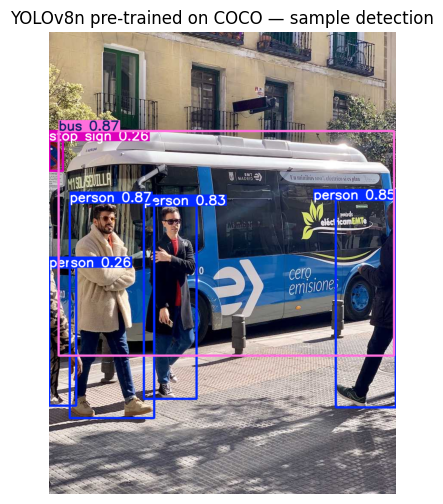

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

pretrained = YOLO("yolov8n.pt")
results = pretrained("https://ultralytics.com/images/bus.jpg")

img = results[0].plot()          # BGR numpy array with boxes drawn
plt.figure(figsize=(10, 6))
plt.imshow(img[..., ::-1])       # BGR -> RGB for matplotlib
plt.axis('off')
plt.title("YOLOv8n pre-trained on COCO — sample detection")
plt.show()

In [ ]:
model = YOLO("yolov8n.pt")

model.train(
    data=yaml_path,
    epochs=5,
    imgsz=640,
    batch=16,
    name='yolov8n-bus-trucks',
    exist_ok=True,
    plots=True,
)

print(f"\nBest weights saved to: {model.trainer.best}")

Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=bus_truck.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n-bus-trucks, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100

In [ ]:
metrics = model.val()
print(f"mAP50     : {metrics.box.map50:.3f}")
print(f"mAP50-95  : {metrics.box.map:.3f}")
print(f"Precision : {metrics.box.mp:.3f}")
print(f"Recall    : {metrics.box.mr:.3f}")

In [ ]:
from torch_snippets import Glob, choose
import matplotlib.pyplot as plt

best_model = YOLO('runs/detect/yolov8n-bus-trucks/weights/best.pt')
val_images = Glob(str(OUT_ROOT / 'images' / 'val' / '*.jpg'))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax in axes.flatten():
    img_path = str(choose(val_images))
    result = best_model(img_path, conf=0.25, verbose=False)[0]
    ax.imshow(result.plot()[..., ::-1])
    ax.axis('off')

plt.suptitle("YOLOv8n fine-tuned: bus/truck detections", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from torch_snippets import show, read

result = best_model(str(choose(val_images)), conf=0.25, verbose=False)[0]

boxes   = result.boxes.xyxy.cpu().numpy().astype(int)
classes = [result.names[int(c)] for c in result.boxes.cls.cpu().numpy()]
scores  = result.boxes.conf.cpu().numpy()
texts   = [f'{cls} {score:.2f}' for cls, score in zip(classes, scores)]

img = read(result.path, 1)   # RGB numpy array
show(img, bbs=boxes, texts=texts, sz=8, text_sz=10)

In [ ]:
import os
from torch_snippets import read, show

train_dir = 'runs/detect/yolov8n-bus-trucks'
for artifact in ['results.png', 'val_batch0_pred.jpg']:
    path = os.path.join(train_dir, artifact)
    if os.path.exists(path):
        show(read(path, 1), sz=14, title=artifact)